# 05 - Inertia

## Purpose

This notebook continues a series working toward an accurate,
mathematically proven servo control loop, built on empirical data. Notebook
01 established the coast back-EMF as a direct speed signal and fitted the
coast friction. Notebook 04 measures the friction from the drive side. This
notebook measures the remaining constant of the mechanical equation, the
inertia, and does so in units the data supports.

The motor's torque constant is unknown, so the inertia is measured as
current per unit acceleration, $J_i$, in amperes per (wiper V/s$^2$). With
it the mechanical equation reads

$$J_i\,\dot\omega = i - i_c\,\mathrm{sign}(\omega) - i_v\,\omega ,$$

where $i$ is the winding current, $\omega$ the output speed in wiper V/s,
and $i_c$, $i_v$ the Coulomb and viscous friction in current units. Every
term is measured. Nothing in it needs the torque constant or the gear
ratio.

This notebook has three jobs:

1. Measure $J_i$ from the rise curve, the speed reached after drive steps
   of five lengths, by integrating the equation over each step with the
   measured current (route A, section 5).
2. Measure $J_i$ a second way, from the coast deceleration of notebook 01
   and the drive-side friction line, and compare (route B, section 6).
3. Establish the repeatability of every estimate across five recordings
   and show which speed signal makes the measurement work (section 7).

**Speed here is never a pot derivative.** Every speed and every
acceleration below is read from the coast back-EMF. The pot appears only as
the thing being tested, in section 7.2, where its own numbers are put beside
the EMF's. That is not a stylistic choice: the pot differenced one tick
apart reports about 23 wiper V/s from a servo that is standing still
(section 7.2), which is four times the fastest speed this notebook measures.

The primary dataset is `sg90-a__dev-v006-D__2s`, one session on a 2-cell
battery: five step recordings, the five spin-down recordings of notebook 01,
and the ten duty-grid recordings of notebooks 00 and 04 for the friction
line. Every coefficient comes from it. The same three campaigns were
captured on a laptop USB port in the same session, and that dataset appears
once, in section 7.1, as a cross-check on the trends. The USB rail droops
about 3.5% across the duty range and dips over 20% on spin-up, so a
coefficient fitted against duty there has the supply's droop folded into it.
The 2-cell rail is flat to about 0.1% over the same range.


## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The board and the servo
are the entries `dev-v006-D` and `sg90-a` in the registry the cell in section
2 prints, and the points this notebook depends on are these.

- A brushed DC motor driven by an H-bridge with 20 kHz PWM, center
  aligned, under slow decay throughout this notebook. **Drive** connects
  the supply across the motor. The OFF portion of each period is **brake**,
  the winding shorted through the two low-side switches. **Coast** turns
  every switch off, so both terminals float.
- A gear train couples the motor to the output shaft. A potentiometer on
  the output shaft is read by the MCU's 12-bit ADC. Position stays in
  wiper volts, speed in wiper V/s, acceleration in wiper V/s$^2$.
- A shunt resistor in the motor return path, amplified, gives the motor
  current channel. Current crosses the shunt only while the bridge drives.
  In brake it recirculates through the low-side switches, so the crest-scan
  sample of a slow-decay period reads the winding current in the drive
  window.
- Both motor terminals are read through resistor dividers, channels
  `vmotor_a` and `vmotor_b`, with the bottom leg of each divider returned to
  a bias node $V_B$ of about 0.63 V, so that a terminal as low as about
  -1.3 V stays readable. Each tap has a 150 pF reservoir capacitor so the
  ADC's sample capacitor can charge quickly from a divider of a few kOhm.
  During coast the difference of the two terminals is the back-EMF
  (notebook 01, section 6.1).
- The ADC, clocked at 24 MHz with 13.5 cycle apertures, runs two
  seven-channel scans per 50 us period, at the crest and trough of the PWM
  counter. Under slow decay the crest scan sees the drive state. The
  controller streams one frame per period with a CRC, and corrupted frames
  become missing samples (verified in section 4).

**The board is a hacked rig.** The board under this session is a
development board that has been reworked by hand several times (the shunt,
the dividers, the bias return, the reservoir capacitors, a repaired
amplifier pad). I know of one defect on it that the next board revision
does not have. The bus telemetry stream couples into the current
amplifier's output, so a shunt sample taken while a frame is going out on
the wire can read a few counts off. On the scan geometry of this firmware
build it does not show at rest (notebook 00, section 5.2, bins the rest
current by position inside the frame and finds it flat within a count),
but one count is 0.9 mA on this board, so a few counts is a few
milliamps, and the friction line of section 5.3 lives on currents of 50 to
100 mA. That is enough to move a low-current fit by a few percent. It is a
known limitation of this board, and I do not code around it anywhere in
this notebook.

Power is a 2-cell battery. The rail reaching the motor is read at the
driven terminal in section 3 and sits at 7.4 to 7.5 V, rising by 0.09 V
between the shortest step and the longest one because the current is lower
in the long steps. On USB the same reading is 4.62 V. Every speed, every
EMF and every current in this notebook is therefore larger than the USB
cross-check of section 7.1 for the supply alone.


## 2. Constants and where they come from

Not one conversion factor is written down in this notebook. The `oscnb`
package carries an entry per board and an entry per servo, and each
dataset's manifest names the pair that produced it, so a capture arrives
with its own constants instead of relying on me to remember which rig was on
the bench that week. Reading a recording checks its own `sense` block, the
shunt, the divider legs, the amplifier gain and VDD as the capture tool
recorded them, against the board its manifest names, and raises rather than
quietly returning numbers scaled by the ratio of two shunts.

The cell below prints three tables: what the dataset holds, the derived
constants of the rig (what the hardware is), and the measured values with
their brackets and provenance (what somebody found when they looked). The
ones this notebook leans on are the converter step, the terminal divider
ratio $r$, and the amperes per count.

With the divider's bottom leg returned to the bias $V_B$, a terminal
voltage $V_t$ reaches the ADC pin as

$$\text{tap} = \frac{V_t}{r} + \frac{r - 1}{r} V_B, \qquad V_t = r\,\text{tap} - (r - 1)\, V_B, \qquad r = \frac{R_\text{top} + R_\text{bot}}{R_\text{bot}} .$$

With the bridge off and no current, both taps read $V_B$ exactly, which is
how the bias is measured per recording (section 3). The two taps do not read
the same bias at rest: they sit 4 counts apart in every recording of this
dataset, against the 18 counts the earlier session showed. So every absolute
terminal voltage below uses the second form with the rest reading of its own
terminal in its own recording, which absorbs the split as an offset, and the
difference $v_A - v_B$ then reads zero at rest.

All drive steps in this notebook are at 30% duty, above both sampling
floors, so every crest-scan current and terminal sample of a drive step is
settled. The floors themselves are marked UNVERIFIED in the board entry and
nothing here sits near them.

Two derived units are specific to this notebook. Speed in wiper V/s comes
from the coast EMF through the slope $k_e$ in V per wiper V/s, remeasured
in section 5.1. The inertia $J_i$ is in A per (wiper V/s$^2$), and the
friction constants $i_c$ and $i_v$ in A and A per (wiper V/s). The
mechanical time constant $J_i / i_v$ is in seconds, since the units of
$\omega$ cancel.

Two caveats carry over from notebook 00. The ADC reference is the design
value, so every voltage and current scales with the true VDD of this unit.
The divider, shunt and gain are design values with unmeasured tolerances.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, curve_fit

import oscnb

# 2S is the primary dataset. The USB rail droops 3.5% across the duty range and
# dips 22% on spin-up, so a coefficient fitted against duty on USB folds the rail
# droop into the duty axis. Every constant below comes from 2S; USB enters once,
# in section 7.1, as a cross-check that the trends point the same way.
ds = oscnb.use("sg90-a__dev-v006-D__2s")
ds_usb = oscnb.datasets.load("sg90-a__dev-v006-D__usb")
board, servo = oscnb.current().board, oscnb.current().servo

Q15 = 32767                  # duty full scale as encoded on the wire
DT = 1.0 / board.tick_hz
DIRS = {1: "forward", -1: "reverse"}
term_V = board.term_v        # Vt = r tap - (r - 1) VB


dataset  sg90-a__dev-v006-D__2s
supply   2s
rig      SG90 clone, unit A on osc-dev-v006 board D (bodged toward rev-2A)



,captures,recordings per capture,names
experiment,,,
breakaway,5,1,sweep
bridge,5,3,"fast, slow, spindown"
grid,10,1,sweep
reversal,5,1,sweep
ripple,5,1,sweep
stepcoast,5,5,"step120, step20, step40, step60, step80"



derived constants (what the hardware is)


value
where            quantity                                           unit                         
board            converter step                                     mV per count           0.8057
                 terminal divider ratio r                                                  3.0606
                 terminal difference                                mV per count           2.4658
                 terminal bias VB                                   mV                   627.9352
                                                                    counts               779.4008
                 driven-low terminal reads                          counts               524.7451
                 motor current                                      mA per count           0.8952
                                                                    counts per A        1117.0909
                 shunt                                              mOhm                  60.0000
                 amplifier gain                                     x                     15.0000
                 rail tap ratio                                                            2.5000
                 sample rate                                        samples per ms        20.0000
                 current settled from (UNVERIFIED)                  % duty                13.3333
                 voltage settled from (UNVERIFIED)                  % duty                13.3333
servo            pot intercept                                      counts               232.0000
                 pot slope                                          counts per degree     19.9600
                 envelope low                                       counts (10 deg)      431.6000
                 envelope high                                      counts (170 deg)    3625.2000
                 runway                                             counts              3193.6000
                 seek guard low                                     counts               432.0000
                 seek guard high                                    counts              3625.0000
servo (measured) gear_ratio_measured [234.73, 234.73] mechanical... :1                   234.7300
                 ripple_order_measured [6, 6] bringup isns-diff ... per motor rev          6.0000
                 kv_measured [7880, 8040] bringup isns-diff run28   RPM/V               7960.0000
                 kt_measured [1.19, 1.21] bringup isns-diff run28   mN-m/A                 1.2000
                 r_motor_measured [4.16, 4.24] bringup isns-diff... Ohm                    4.2000
                 l_motor_measured [0.45, 0.55] bringup isns-diff... mH                     0.5000
                 stall_current_measured [1.45, 1.55] bringup isn... A                      1.5000
                 stall_torque_measured [1.75, 1.85] bringup isns... mN-m                   1.8000
                 free_run_current_measured [0.078, 0.084] bringu... A                      0.0810
                 r_winding_measured [4.3, 4.8] nb03, full duty o... Ohm                    4.5000
                 pot_scale_measured [18.07, 18.49] ripple tach v... counts/deg            18.2900
                 coast_bemf_slope_measured [0.19, 0.204] nb01, c... V per wiper V/s        0.1970
                 ke_measured [7.29, 7.49] ripple speed + coast B... mV per motor rev/s     7.3670


measured values (what someone found when they looked)


value                 unit           bracket  \
where quantity                                                            
board vb_bias            781.000               counts        [775, 783]   
      rail_droop_usb      -3.500  % over 20-100% duty          [-4, -3]   
      opa_noise_floor      2.200           counts RMS          [2, 2.4]   
      esd_clamp_skew       1.800               V bemf        [1.7, 1.9]   
servo gear_ratio         234.730                   :1  [234.73, 234.73]   
      ripple_order         6.000        per motor rev            [6, 6]   
      kv                7960.000                RPM/V      [7880, 8040]   
      kt                   1.200               mN-m/A      [1.19, 1.21]   
      r_motor              4.200                  Ohm      [4.16, 4.24]   
      l_motor              0.500                   mH      [0.45, 0.55]   
      stall_current        1.500                    A      [1.45, 1.55]   
      stall_torque         1.800                 mN-m      [1.75, 1.85]   
      free_run_current     0.081                    A    [0.078, 0.084]   
      r_winding            4.500                  Ohm        [4.3, 4.8]   
      pot_scale           18.290           counts/deg    [18.07, 18.49]   
      coast_bemf_slope     0.197      V per wiper V/s     [0.19, 0.204]   
      ke                   7.367   mV per motor rev/s      [7.29, 7.49]   

                                                                   source  \
where quantity                                                              
board vb_bias                     Hi-Z rest baseline, 2S grid + stepcoast   
      rail_droop_usb                      2S vs USB grid, 5 captures each   
      opa_noise_floor                             bringup isns-diff run29   
      esd_clamp_skew                           bringup isns-diff findings   
servo gear_ratio                          mechanical/sg90/measurements.py   
      ripple_order                           bringup isns-diff runs 25-27   
      kv                                          bringup isns-diff run28   
      kt                                          bringup isns-diff run28   
      r_motor                                     bringup isns-diff run28   
      l_motor                                     bringup isns-diff run28   
      stall_current                               bringup isns-diff run28   
      stall_torque                                bringup isns-diff run28   
      free_run_current                            bringup isns-diff run28   
      r_winding                              nb03, full duty onset anchor   
      pot_scale         ripple tach vs counted gear ratio, 2S grid 30-...   
      coast_bemf_slope                                      nb01, chain 2   
      ke                ripple speed + coast BEMF, 2S bridge spindown,...   

                                                                   caveat  
where quantity                                                             
board vb_bias           nominal 779 from the 200/47 network, so 0.3%. ...  
      rail_droop_usb    USB also dips -21.8% transiently at 0.76 A; 2S...  
      opa_noise_floor   arm-B external network at G15; the internal PG...  
      esd_clamp_skew    above this the A-side ESD clamp skews the divi...  
servo gear_ratio        (47*38*32*23)/(10*10*8*7), counted teeth on th...  
      ripple_order      3-segment commutator x 2 brushes; optical tach...  
      kv                bare can, +/-1% HSI scale; pinion stayed on th...  
      kt                                                                   
      r_motor           bare can. nb03 got 4.5 [4.3, 4.8] in-servo via...  
      l_motor                            locked-rotor burst, tau_e 102 us  
      stall_current                                       = V/R confirmed  
      stall_torque                                                         
      free_run_current                                         at duty 65

## 3. Capture method

Three experiments of the primary dataset enter this notebook, all under
`telemetry/sg90-a__dev-v006-D__2s/`.

- **Step series** (`stepcoast/`, five captures). Each capture holds five
  recordings, one per step length of 20, 40, 60, 80 and 120 ms. Each
  recording has five segments. Segment 0 is a one-second baseline with the
  bridge disabled. Segment 1 is a forward drive step at 30% duty of the
  named length. Segment 2 is 300 ms of coast. Segments 3 and 4 repeat the
  pair in reverse. The coast segments start when the drive command ends, so
  the motor enters them at the speed the step reached.
- **Spin-down series** (`bridge/`, the five captures of notebook 01). The
  `spindown` recording of each capture holds 80 ms drive steps at 20%, 30%
  and 40% duty, each followed by 400 ms of coast or brake, forward then
  reverse. Its coast segments give the EMF-to-speed slope and the coast
  friction, and its own drive steps give the rail that the coast window's
  discriminator needs.
- **Duty grid** (`grid/`, the ten captures of notebooks 00 and 04). Drive
  steps at 5% to 100% duty in 5% increments, forward then reverse, each
  window sized so the step covers about the same travel (150 ms at 100%
  duty out to 842 ms at 15%). They give the drive-side friction line of
  section 5.3.

Before every drive step the servo is repositioned at 15% duty toward the
far end of travel, so the step has room to accelerate. The mechanism is
still moving from that repositioning move when the step begins, in the
direction opposite to the step, so every step starts from a negative,
unknown speed. Section 5.3 treats that entry speed as a fitted parameter
and section 7.2 shows why the pot cannot supply it.

**Data acceptance.** A recording is accepted only if the host counted zero
dropped frames in all its segments. Section 4 re-verifies this from the
data itself.

Each row of a recording is one 50 us sample with the segment number, the
commanded duty, the direction, the tick counter, the firmware's validity
flag, the position, the crest-scan shunt (`current_raw`), the trough-scan
shunt (`current_trough`), and the crest-scan terminals (`vmotor_a`,
`vmotor_b`).

The segment-0 baseline of every recording gives three per-recording
constants, the shunt amplifier's bias (mean of `current_raw`) and the rest
reading of each terminal (median of `vmotor_a` and of `vmotor_b`), which are
the $V_B$ of terminal A and of terminal B in the tap formula. The rail of a
step recording is the median driven terminal over the valid samples of its
two drive steps, each direction read on its own terminal with that
terminal's own rest reading. The last column of the table sets that beside
the rail tap the firmware recorded in the metadata at rest, converted with
the board entry's own divider; section 10 opens the 20 to 22% gap between them.


In [2]:
STEP_MS = (20, 40, 60, 80, 120)
KEEP = ["seg", "cmd_duty_q15", "dir", "tick", "window_valid", "pos",
        "current_raw", "current_trough", "vmotor_a", "vmotor_b"]

def prep(rec):
    # One recording, trimmed to the channels this notebook reads. Derived
    # columns: duty_pct (signed percent), mag_pct (rounded magnitude), and the
    # per-recording baseline constants bias (shunt amplifier offset), vb
    # (terminal A rest reading), vb_b (terminal B rest reading).
    df = rec.frame()[KEEP].astype("int32")
    meta = rec.meta
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["mag_pct"] = df["duty_pct"].abs().round().astype(int)
    base = df[df["seg"] == 0]
    df["bias"] = base["current_raw"].mean()
    df["vb"] = base["vmotor_a"].median()
    df["vb_b"] = base["vmotor_b"].median()
    sched = meta.get("schedule", [])
    if any(":" in s for s in sched):
        kinds = ["baseline"] + [
            "drive" if ":" not in s else s.split(":")[0]
            for s in sched * (df["seg"].max() // len(sched))
        ]
        df["kind"] = df["seg"].map(dict(enumerate(kinds)))
    return df, meta

def sweep(dataset, experiment, capture, name="sweep"):
    # frame() checks the recording's own `sense` block against the board its
    # dataset manifest names, so a capture read under the wrong constants
    # raises here rather than producing a plausible wrong number.
    rec, = [r for r in dataset.recordings(experiment, capture) if r.name == name]
    return prep(rec)

def rail_V(df):
    # Median driven terminal over the valid drive samples at 20% duty and
    # above, each direction read on its own terminal with that terminal's
    # own rest reading, then averaged.
    v = df[(df["seg"] > 0) & (df["window_valid"] == 1) & (df["mag_pct"] >= 20)]
    vals = []
    for sel, col, vb in ((v["duty_pct"] > 0, "vmotor_a", "vb"), (v["duty_pct"] < 0, "vmotor_b", "vb_b")):
        if sel.any():
            vals.append(term_V(np.median(v.loc[sel, col]), df[vb].iloc[0]))
    return float(np.mean(vals))

steps_raw = {c: {ms: sweep(ds, "stepcoast", c, f"step{ms}") for ms in STEP_MS}
             for c in ds.captures("stepcoast")}
spin_raw = {c: sweep(ds, "bridge", c, "spindown") for c in ds.captures("bridge")}
grid_raw = {c: sweep(ds, "grid", c)[0] for c in ds.captures("grid")}

rows = []
for name, sweeps in steps_raw.items():
    a = [sweeps[ms][0]["vb"].iloc[0] for ms in STEP_MS]
    b = [sweeps[ms][0]["vb_b"].iloc[0] for ms in STEP_MS]
    rails = [rail_V(sweeps[ms][0]) for ms in STEP_MS]
    tap = [board.vsys_v(sweeps[ms][1]["vbus_counts"]) for ms in STEP_MS]
    rows.append({
        "recording": name,
        "VB_A [counts]": a[0],
        "VB_B [counts]": b[0],
        "B minus A [counts]": b[0] - a[0],
        "A spread over sweeps [counts]": max(a) - min(a),
        "B spread over sweeps [counts]": max(b) - min(b),
        "VB_A minus nominal [mV]": (a[0] * board.v_adc_per_count - board.vb_nom_v) * 1e3,
        "rail, 20 ms sweep [V]": rails[0],
        "rail, 120 ms sweep [V]": rails[-1],
        "rail tap at rest [V]": float(np.mean(tap)),
    })
pd.DataFrame(rows).set_index("recording").round(3)


,VB_A [counts],VB_B [counts],B minus A [counts],A spread over sweeps [counts],B spread over sweeps [counts],VB_A minus nominal [mV],"rail, 20 ms sweep [V]","rail, 120 ms sweep [V]",rail tap at rest [V]
recording,,,,,,,,,
capture-1,778.0,782.0,4.0,0.0,0.0,-1.129,7.412,7.501,6.142
capture-2,778.0,782.0,4.0,0.0,0.0,-1.129,7.403,7.493,6.137
capture-3,778.0,782.0,4.0,0.0,0.0,-1.129,7.393,7.485,6.130
capture-4,778.0,782.0,4.0,0.0,0.0,-1.129,7.386,7.477,6.124
capture-5,778.0,782.0,4.0,0.0,0.0,-1.129,7.377,7.469,6.115


Terminal A rests at 778 counts and terminal B at 782 in every recording,
a 4-count split that does not move across the five step lengths of a
capture, or across captures. Terminal A sits 1.1 mV below the nominal bias.
The earlier session on this board read an 18-count split, so whatever the
rework changed, it left the two taps far closer together than they were.

The rail read during the 120 ms steps is 0.09 V **above** the rail read
during the 20 ms steps of the same capture, because the current is lower in
the long steps (section 5.2) and the source resistance of the pack takes the
difference. Over the five captures the rail falls from 7.50 to 7.47 V, which
is the pack discharging over the session. The rail enters this notebook only
as the discriminator threshold of the coast window.

The last column is a different measurement of the same rail: the rail tap
the firmware sampled at rest, converted with the divider the board entry
declares for it. It reads 6.13 V where the driven terminal reads 7.48 V, and
the same gap appears on USB, 3.86 V against 4.62 V. That is 22% on one
supply and 20% on the other. Section 10 takes it up. Nothing below depends on the rail tap.

## 4. Data integrity

The transport turns a corrupted frame into a missing sample. The table
recomputes the missing-sample count of every recording from the tick column,
which increments by one per sample within a segment, summed over the
recordings of each capture.


In [3]:
def missing_samples(df):
    missing = 0
    for _, seg in df.groupby("seg"):
        ticks = seg["tick"].to_numpy()
        missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
    return missing

rows = []
for name, sweeps in steps_raw.items():
    dfs = [sweeps[ms][0] for ms in STEP_MS]
    rows.append({"campaign": "step series", "recording": name, "sweeps": len(dfs),
                 "samples": sum(len(d) for d in dfs), "segments": sum(d["seg"].nunique() for d in dfs),
                 "missing_samples": sum(missing_samples(d) for d in dfs)})
for name, (df, _) in spin_raw.items():
    rows.append({"campaign": "spin-down series", "recording": name, "sweeps": 1,
                 "samples": len(df), "segments": df["seg"].nunique(),
                 "missing_samples": missing_samples(df)})
for name, df in grid_raw.items():
    rows.append({"campaign": "duty grid", "recording": name, "sweeps": 1,
                 "samples": len(df), "segments": df["seg"].nunique(),
                 "missing_samples": missing_samples(df)})
pd.DataFrame(rows).set_index(["campaign", "recording"])


sweeps  samples  segments  missing_samples
campaign         recording                                             
step series      capture-1        5   172800        25                0
                 capture-2        5   172800        25                0
                 capture-3        5   172800        25                0
                 capture-4        5   172800        25                0
                 capture-5        5   172800        25                0
spin-down series capture-1        1   135200        25                0
                 capture-2        1   135200        25                0
                 capture-3        1   135200        25                0
                 capture-4        1   135200        25                0
                 capture-5        1   135200        25                0
duty grid        capture-1        1   336800        41                0
                 capture-2        1   336800        41                0
                 capture-3        1   336800        41                0
                 capture-4        1   336800        41                0
                 capture-5        1   336800        41                0
                 capture-6        1   336800        41                0
                 capture-7        1   336800        41                0
                 capture-8        1   336800        41                0
                 capture-9        1   336800        41                0
                 capture-10       1   336800        41                0

Every recording of every capture has zero missing samples.

## 5. The rise curve

### 5.1 Coast-entry EMF and speed against step length

The speed at the end of a drive step is read from the back-EMF in the
first milliseconds of the coast that follows. Notebook 01 established the
method. During coast the difference of the two terminals is the EMF,
$e = r\,(\text{tap}_A - \text{tap}_B)$ less the rest split, taken positive
along the drive direction. The first three coast samples are excluded. The
first one still reads the drive rail, and the next one or two are taken
while the bridge is still switching and can read anywhere from -3.1 V to
the rail on the terminal difference. From the third sample on the lowest
reading in this dataset is 0.23 V, so the coast entry is taken from the
third sample onward and never from the first two. Any later sample whose
terminal sum exceeds the rail is dropped as well (the winding current is
still dying through the body diodes there). The EMF is linear in speed
with a slope $k_e$ measured from the spin-down coasts, where the pot's
travel over a whole segment calibrates the EMF's integral.

The slope and the coast friction are recomputed here from the spin-down
recordings, with the fit of notebook 01 (section 6.2 there). The model is
$\dot v = -(a + b\,v)$ for $v > 0$, fitted jointly to the EMF traces of
the six coast segments of a recording with one $(a, b)$ per recording and
one entry value per segment, and also to the position traces (the pot
route). The terminal-route $a$ is converted to wiper units with the
recording's own slope.

In [4]:
SKIP = 3       # coast samples excluded at the start of every coast segment
FIT_N = 5000   # 250 ms of every coast segment enters the friction fit

def coast_segments(sp, rail):
    # Per coast segment: position and EMF along the entry direction, the
    # terminal sum, and the sample mask of notebook 01.
    out = []
    for seg_id, seg in sp[sp["kind"] == "coast"].groupby("seg"):
        d = int(seg["dir"].iloc[0])
        vb, vb_b = seg["vb"].iloc[0], seg["vb_b"].iloc[0]
        vA, vB = term_V(seg["vmotor_a"].to_numpy(), vb), term_V(seg["vmotor_b"].to_numpy(), vb_b)
        ssum = vA + vB
        out.append({
            "seg": seg_id, "dir": d,
            "entry_pct": int(sp.loc[sp["seg"] == seg_id - 1, "mag_pct"].iloc[0]),
            "p": seg["pos"].to_numpy() * d * board.v_adc_per_count,
            "e": (vA - vB) * d,
            "mask": (np.arange(len(seg)) >= SKIP) & (ssum < rail),
        })
    return out

def speed_model(t, v0, a, b):
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    return np.where(t < t_stop, (v0 + a / b) * np.exp(-b * np.minimum(t, t_stop)) - a / b, 0.0)

def traj(t, p0, v0, a, b):
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    tt = np.minimum(t, t_stop)
    return p0 + (v0 + a / b) * (1 - np.exp(-b * tt)) / b - (a / b) * tt

def joint_fit(segs, signal, use_mask, has_p0):
    # Shared (a, b), per-segment start value (and offset when has_p0).
    t = np.arange(FIT_N) * DT
    per = 2 if has_p0 else 1
    def resid(x):
        r = []
        for i, c in enumerate(segs):
            y = c[signal][:FIT_N]
            m = c["mask"][:FIT_N] if use_mask else np.ones(len(y), bool)
            if has_p0:
                model = traj(t, x[2 + per * i], x[3 + per * i], x[0], x[1])
            else:
                model = speed_model(t, x[2 + i], x[0], x[1])
            r.append((model - y)[m])
        return np.concatenate(r)
    x0, lb = [30.0, 5.0], [0.0, 0.0]
    for c in segs:
        y = c[signal]
        if has_p0:
            x0 += [y[0], 5.0]
            lb += [-np.inf, 0.0]
        else:
            x0 += [max(y[3], 0.1)]
            lb += [0.0]
    res = least_squares(resid, x0, bounds=(lb, np.inf))
    return {"a": res.x[0], "b": res.x[1], "rms": np.sqrt(np.mean(res.fun ** 2))}

rows = []
for name, (sp, _) in spin_raw.items():
    segs = coast_segments(sp, rail_V(sp))
    ratios = []
    for c in segs:
        travel = np.median(c["p"][-1000:]) - np.median(c["p"][:3])
        ratios.append(np.sum(c["e"][c["mask"]]) * DT / travel)
    slope = np.mean(ratios)
    term = joint_fit(segs, "e", True, False)
    pot = joint_fit(segs, "p", False, True)
    entry = [c["e"][c["mask"]][:20].mean() / slope for c in segs]
    rows.append({
        "recording": name,
        "k_e [V per wiper V/s]": slope,
        "a, terminal route [wiper V/s2]": term["a"] / slope,
        "b, terminal route [1/s]": term["b"],
        "a/b, terminal route [wiper V/s]": term["a"] / slope / term["b"],
        "a, pot route [wiper V/s2]": pot["a"],
        "b, pot route [1/s]": pot["b"],
        "coast entry, lowest [wiper V/s]": min(entry),
        "coast entry, highest [wiper V/s]": max(entry),
    })
coast_tab = pd.DataFrame(rows).set_index("recording")
K_E = coast_tab["k_e [V per wiper V/s]"].mean()
A_COAST = coast_tab["a, terminal route [wiper V/s2]"]
B_COAST = coast_tab["b, terminal route [1/s]"]
# The friction line of section 5.3 is fitted over the speed range the coast
# segments actually cover, so the ceiling is read from them and not declared.
V_MATCH = float(np.ceil(coast_tab["coast entry, highest [wiper V/s]"].max()))

def with_summary(tab):
    s = tab.agg(["mean", "min", "max"])
    s.loc["cv [%]"] = tab.std() / tab.mean().abs() * 100
    if isinstance(tab.index, pd.MultiIndex):
        s.index = pd.MultiIndex.from_tuples([(k, "") for k in s.index], names=tab.index.names)
    return pd.concat([tab, s])

with_summary(coast_tab).round(3)

,k_e [V per wiper V/s],"a, terminal route [wiper V/s2]","b, terminal route [1/s]","a/b, terminal route [wiper V/s]","a, pot route [wiper V/s2]","b, pot route [1/s]","coast entry, lowest [wiper V/s]","coast entry, highest [wiper V/s]"
capture-1,0.283,43.653,2.746,15.898,37.244,4.877,3.555,8.366
capture-2,0.288,40.808,2.633,15.497,36.842,4.177,3.512,8.250
capture-3,0.294,39.425,2.800,14.079,37.102,4.130,3.417,8.052
capture-4,0.294,39.912,2.740,14.566,38.513,3.934,3.451,7.979
capture-5,0.287,39.801,2.887,13.786,34.061,5.043,3.491,8.231
mean,0.289,40.720,2.761,14.765,36.752,4.432,3.485,8.176
min,0.283,39.425,2.633,13.786,34.061,3.934,3.417,7.979
max,0.294,43.653,2.887,15.898,38.513,5.043,3.555,8.366
cv [%],1.663,4.215,3.359,6.140,4.453,11.141,1.533,1.924


The slope is 0.289 V per wiper V/s on average (0.283 to 0.294 across
captures, a 1.7% spread), the value used for every EMF-to-speed conversion
below. Section 7.1 gets 0.2891 from the USB captures against 0.2891 here. The two
means land 0.02% apart, which is closer than either of them deserves given
the 1.7% each spreads over its own captures, so read it as agreement within
the spread and not as four significant figures. It is the behaviour a
back-EMF slope should show: it is a ratio of an EMF integral to a travel,
and the supply cancels out of it.

The coast friction is 40.7 wiper V/s$^2$ Coulomb (39.4 to 43.7) and 2.76 1/s
viscous (2.63 to 2.89) by the terminal route, with a ratio $a/b$ of 14.8
wiper V/s. The pot route puts the Coulomb term at 36.8 and, unlike the
earlier USB session where it could not resolve the viscous term at all,
returns 4.43 1/s for it. The two routes now disagree on how to split one
deceleration between a constant term and a speed-proportional one: the pot
route takes 10% off $a$ and puts 60% onto $b$. Both fit the same curve, and
section 6 is where that split starts to matter.

The coast entry speeds of these segments run 3.4 to 8.4 wiper V/s, so
section 5.3 matches the friction line to steps at or below 9 wiper V/s. That
ceiling is read from the coast entries rather than declared, so it follows
the supply instead of having to be re-tuned for it.

The step series is read the same way. For every drive step the coast-entry
EMF is the mean of coast samples 3 to 23 (0.15 to 1.15 ms after the drive
ends) that pass the mask, and the speed at the end of the step is that EMF
divided by $k_e$. The figure shows the EMF against step length for every
capture and both directions, and the first 3 ms of the coast EMF of one
capture, where the averaging window sits.


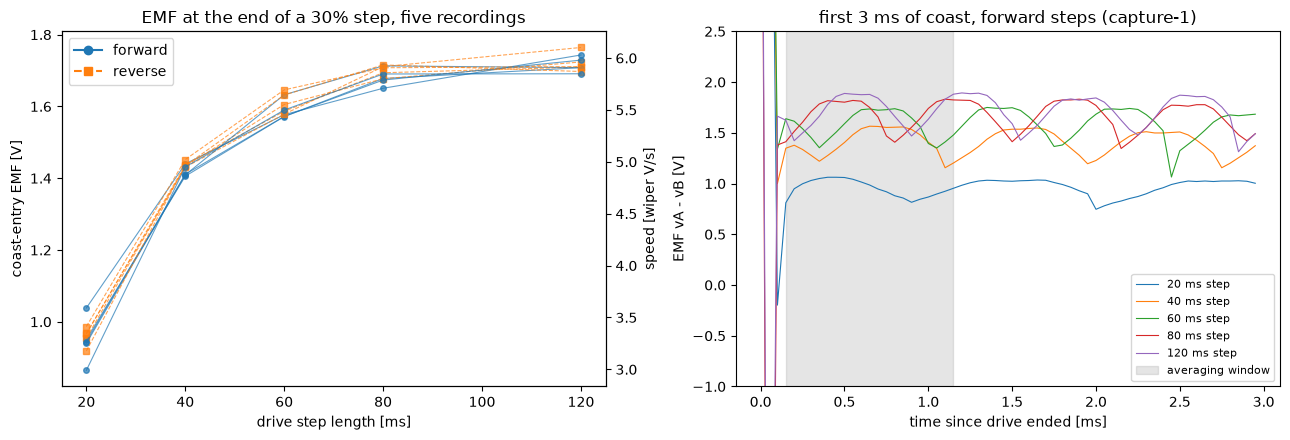

emf_V  emf_spread_pct  emf_sd_within_V  samples  omega_T  \
direction step_ms                                                             
forward   20       0.948           6.501            0.110     21.0    3.278   
          40       1.419           1.073            0.148     21.0    4.909   
          60       1.589           1.611            0.133     21.0    5.494   
          80       1.681           1.363            0.158     21.0    5.814   
          120      1.716           1.191            0.149     21.0    5.935   
reverse   20       0.959           2.621            0.133     21.0    3.316   
          40       1.438           0.586            0.107     21.0    4.972   
          60       1.610           1.795            0.123     21.0    5.567   
          80       1.701           0.921            0.127     21.0    5.883   
          120      1.721           1.501            0.139     21.0    5.953   

                   travel_V  
direction step_ms            
forward   20         -0.001  
          40          0.090  
          60          0.202  
          80          0.309  
          120         0.561  
reverse   20         -0.005  
          40          0.084  
          60          0.197  
          80          0.307  
          120         0.564

In [5]:
ENTRY_LO, ENTRY_HI = 3, 23   # coast samples averaged for the coast-entry EMF

def step_records(name, sweeps, k_e=None):
    k_e = K_E if k_e is None else k_e
    out = []
    for ms in STEP_MS:
        df = sweeps[ms][0]
        vb, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
        bias, rail = df["bias"].iloc[0], rail_V(df)
        for s in (1, 3):
            drv, co = df[df["seg"] == s], df[df["seg"] == s + 1]
            d = int(drv["dir"].iloc[0])
            vA, vB = term_V(co["vmotor_a"].to_numpy(), vb), term_V(co["vmotor_b"].to_numpy(), vb_b)
            e = (vA - vB) * d
            k = np.arange(len(e))
            sel = (k >= ENTRY_LO) & (k <= ENTRY_HI) & (vA + vB < rail)
            cur = (drv["current_raw"].to_numpy() - bias) * board.a_per_count
            ok = drv["window_valid"].to_numpy() == 1
            cur = pd.Series(np.where(ok, cur, np.nan)).ffill().bfill().to_numpy()
            p = drv["pos"].to_numpy() * board.v_adc_per_count * d
            t = np.arange(len(p)) * DT
            out.append({
                "recording": name, "step_ms": ms, "dir": d, "T_s": len(p) * DT,
                "emf_V": e[sel].mean(), "emf_sd_V": e[sel].std(), "emf_n": int(sel.sum()),
                "omega_T": e[sel].mean() / k_e,
                "cur": cur, "pos": p, "emf_trace": e,
                "w0_pot": np.polyfit(t[:100], p[:100], 1)[0],       # first 5 ms
                "wT_pot": np.polyfit(t[-100:], p[-100:], 1)[0],     # last 5 ms
                "travel_V": p[-1] - p[0],
            })
    return out

step_list = sum((step_records(n, s) for n, s in steps_raw.items()), [])
steps = pd.DataFrame(step_list)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, g in steps.groupby("recording"):
    for d, mk in ((1, "-o"), (-1, "--s")):
        gg = g[g["dir"] == d].sort_values("step_ms")
        axes[0].plot(gg["step_ms"], gg["emf_V"], mk, ms=4, lw=0.8, alpha=0.7,
                     color="tab:blue" if d > 0 else "tab:orange")
axes[0].plot([], [], "-o", color="tab:blue", label="forward")
axes[0].plot([], [], "--s", color="tab:orange", label="reverse")
axes[0].set_xlabel("drive step length [ms]")
axes[0].set_ylabel("coast-entry EMF [V]")
axes[0].set_title("EMF at the end of a 30% step, five recordings")
axes[0].legend()
ax2 = axes[0].twinx()
ax2.set_ylim(np.array(axes[0].get_ylim()) / K_E)
ax2.set_ylabel("speed [wiper V/s]")
first = steps[(steps["recording"] == next(iter(steps_raw))) & (steps["dir"] == 1)]
for _, row in first.sort_values("step_ms").iterrows():
    e = row["emf_trace"][:60]
    axes[1].plot(np.arange(len(e)) * DT * 1e3, e, "-", lw=0.8, label=f"{row['step_ms']} ms step")
axes[1].axvspan(ENTRY_LO * DT * 1e3, ENTRY_HI * DT * 1e3, color="grey", alpha=0.2, label="averaging window")
axes[1].set_ylim(-1, 2.5)
axes[1].set_xlabel("time since drive ended [ms]")
axes[1].set_ylabel("EMF vA - vB [V]")
axes[1].set_title(f"first 3 ms of coast, forward steps ({first['recording'].iloc[0]})")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

DIRS = {1: "forward", -1: "reverse"}
entry = steps.assign(direction=steps["dir"].map(DIRS)).groupby(["direction", "step_ms"]).agg(
    emf_V=("emf_V", "mean"), emf_spread_pct=("emf_V", lambda s: s.std() / s.mean() * 100),
    emf_sd_within_V=("emf_sd_V", "mean"), samples=("emf_n", "mean"),
    omega_T=("omega_T", "mean"), travel_V=("travel_V", "mean"))
entry.round(3)

Findings:

- The coast-entry EMF rises from 0.948 V at 20 ms to 1.716 V at 120 ms
  forward (0.959 to 1.721 V reverse), which is 3.3 to 5.9 wiper V/s. The
  rise is steep between 20 and 40 ms and nearly flat from 80 to 120 ms,
  the shape of a first-order approach to a steady speed near 6.0 wiper
  V/s, which section 5.3 fits.
- The spread across the five captures is under 1.8% at 40 ms and above. At
  20 ms it is 6.5% forward and 2.6% reverse, the one step short enough for
  the entry speed to matter (section 5.3).
- The net travel of a 20 ms step is about -1 mV: the step ends with the
  mechanism a hair behind where it started, because the first half of it is
  spent stopping the repositioning move. The end speed is nonetheless
  3.3 wiper V/s forward. A position-based reading of that step would call
  the average speed negative while the EMF says the shaft is turning at
  half its steady speed, which is the whole case for the EMF axis in one
  row of a table.
- The EMF in the averaging window is flat to within its ripple. The first
  sample reads the drive rail, the second and third carry the bridge
  switching, and all three are excluded by the mask.

### 5.2 Drive current during the step

The current that accelerates the motor is the per-sample crest-scan shunt
reading of the drive step, bias subtracted. The figure shows it for the
five step lengths of one capture, forward. The table summarizes the
trace by step length, pooled over captures and directions, and fits the
tail of the 60, 80 and 120 ms steps (from 10 ms in) with a single
exponential $i(t) = i_{ss} + A\,e^{-t/\tau_i}$, the form notebook 04 uses
on the duty grid.


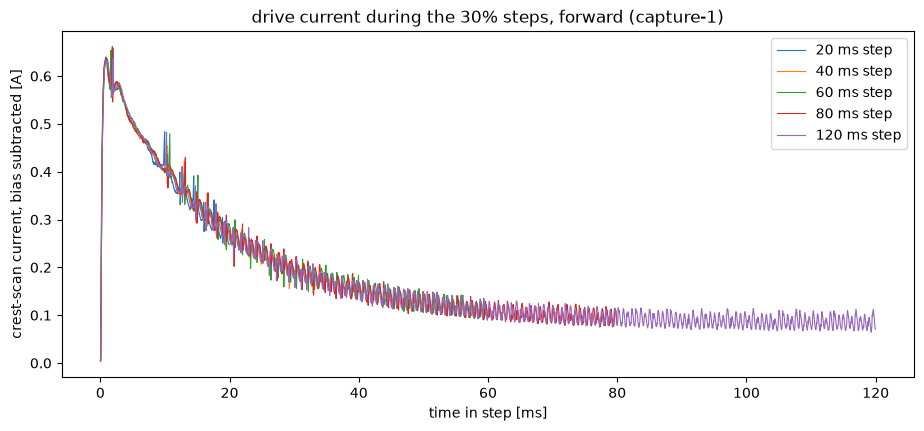

,i_at_0.5ms_A,i_peak_A,t_peak_ms,i_mean_A,i_last_2ms_A,peak_over_last,tail_i_ss_A,tail_tau_ms
step_ms,,,,,,,,
20,0.563,0.661,2.110,0.409,0.273,2.422,NaN,NaN
40,0.553,0.656,2.290,0.303,0.150,4.363,NaN,NaN
60,0.565,0.660,2.005,0.242,0.107,6.155,0.089,17.656
80,0.558,0.651,2.210,0.205,0.092,7.115,0.086,18.175
120,0.565,0.657,2.090,0.166,0.082,8.044,0.083,18.719


In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for _, row in first.sort_values("step_ms").iterrows():
    ax.plot(np.arange(len(row["cur"])) * DT * 1e3, row["cur"], lw=0.8, label=f"{row['step_ms']} ms step")
ax.set_xlabel("time in step [ms]")
ax.set_ylabel("crest-scan current, bias subtracted [A]")
ax.set_title(f"drive current during the 30% steps, forward ({first['recording'].iloc[0]})")
ax.legend()
plt.show()

def i_model(t, i_ss, A, tau):
    return i_ss + A * np.exp(-t / tau)

TAIL_SKIP = 200   # 10 ms, excluded from the exponential fit of the current tail

rows = []
for _, row in steps.iterrows():
    c = row["cur"]
    r = {"step_ms": row["step_ms"], "i_at_0.5ms_A": c[10], "i_peak_A": c.max(),
         "t_peak_ms": int(c.argmax()) * DT * 1e3, "i_mean_A": c.mean(),
         "i_last_2ms_A": c[-40:].mean(), "peak_over_last": c.max() / c[-40:].mean()}
    if row["step_ms"] >= 60:
        t = np.arange(len(c) - TAIL_SKIP) * DT
        (i_ss, A, tau), _ = curve_fit(i_model, t, c[TAIL_SKIP:], p0=[c[-1], c[TAIL_SKIP] - c[-1], 0.02])
        r.update({"tail_i_ss_A": i_ss, "tail_tau_ms": tau * 1e3})
    rows.append(r)
current_tab = pd.DataFrame(rows).groupby("step_ms").mean()
current_tab.round(3)


Findings:

- The current rises from the bias to about 0.56 A within the first 0.5 ms
  of every step, the inductive rise against the winding, and peaks at
  0.65 to 0.66 A between 2.0 and 2.3 ms in. In this window the motor is
  still moving backward from the repositioning move, and its EMF adds to the
  applied voltage. The peak is 8.0 times the 0.083 A the same step settles
  to at 120 ms, on a rail of 7.5 V and a winding of about 4.5 Ohm.
- From there the current falls as the motor reverses and speeds up, to
  0.27 A at the end of the 20 ms step and 0.082 A at the end of the 120 ms
  step, a factor of 2.4 to 8.0 from peak to end. The step-mean current
  falls from 0.41 A at 20 ms to 0.17 A at 120 ms. A model that drives the
  inertia with the mean current is therefore wrong by design, and section
  5.3 shows by how much.
- The tail of the long steps follows one exponential with $\tau_i$ of
  17.7 to 18.7 ms toward a floor of 0.083 to 0.089 A, and the duty grid
  reads 19.6 to 20.5 ms for the same constant. The floor is the steady
  drive current at 30% duty, the friction current at that speed.

### 5.3 Route A, the rise curve fitted with the measured current

The equation of the purpose section is integrated over every step with
the measured current trace,

$$\omega(T) = \omega_0 + \frac{1}{J_i}\int_0^T \big(i(t) - i_c\,\mathrm{sign}\,\omega(t) - i_v\,\omega(t)\big)\,dt ,$$

by forward Euler at the sample rate, and $\omega(T)$ is matched to the
coast-entry speed of the step. The unknowns per capture are $J_i$ and
one entry speed $\omega_0$ per direction, three parameters for ten
measured speeds, on the premise that the repositioning move leaves the
mechanism at about the same speed before every step of a direction. The
fit weighs all ten speeds equally.

The friction line $i = i_c + i_v\,\omega$ per direction comes from the
duty grid with the method of notebook 04, recomputed here so the numbers
are traceable within this notebook. For each grid step at or above 15%
duty, the current after the first 10 ms is fitted with the exponential of
section 5.2 to extrapolate the steady current, and the position over the
same window is fitted with the matching first-order trajectory to
extrapolate the steady speed. The line is fitted through the steps whose
steady speed is at or below the ceiling section 5.1 read off the coast
entries, 9.0 wiper V/s, which is the range the coast segments cover.


In [7]:
GRID_SKIP = 200     # first 10 ms of each grid step excluded from the extrapolation

def grid_steps(name, df):
    out = []
    for seg_id, seg in df[(df["seg"] > 0) & (df["mag_pct"] >= 15)].groupby("seg"):
        d = np.sign(seg["duty_pct"].iloc[0])
        p = seg["pos"].to_numpy() * board.v_adc_per_count * d
        cur = (seg["current_raw"].to_numpy() - seg["bias"].iloc[0]) * board.a_per_count
        ok = seg["window_valid"].to_numpy() == 1
        t = np.arange(len(p) - GRID_SKIP) * DT
        c, tc = cur[GRID_SKIP:][ok[GRID_SKIP:]], t[ok[GRID_SKIP:]]
        (i_ss, A, tau), _ = curve_fit(i_model, tc, c, p0=[c[-1], c[0] - c[-1], 0.02],
                                      bounds=([0, -np.inf, 0.002], [np.inf, np.inf, 0.5]))
        g = tau * (1 - np.exp(-t / tau))
        X = np.column_stack([np.ones_like(t), t - g, g])
        p0, v_ss, v0 = np.linalg.lstsq(X, p[GRID_SKIP:], rcond=None)[0]
        out.append({"recording": name, "mag_pct": int(round(abs(seg["duty_pct"].iloc[0]))),
                    "dir": int(d), "v_ss": v_ss, "i_ss": i_ss, "tau_ms": tau * 1e3})
    return out

grid = pd.DataFrame(sum((grid_steps(n, df) for n, df in grid_raw.items()), []))
I_C, I_V = {}, {}
rows = []
for d, label in DIRS.items():
    g = grid[(grid["dir"] == d) & (grid["v_ss"] <= V_MATCH)]
    k = np.polyfit(g["v_ss"], g["i_ss"], 1)
    I_C[d], I_V[d] = k[1], k[0]
    per = np.array([np.polyfit(gg["v_ss"], gg["i_ss"], 1) for _, gg in g.groupby("recording")])
    rows.append({"direction": label, "steps": len(g), "i_c [A]": k[1], "i_v [A per wiper V/s]": k[0],
                 "i_c / i_v [wiper V/s]": k[1] / k[0],
                 "i_c per-recording cv [%]": per[:, 1].std() / per[:, 1].mean() * 100,
                 "i_v per-recording cv [%]": per[:, 0].std() / per[:, 0].mean() * 100,
                 "grid tau_i [ms]": g["tau_ms"].mean()})
friction = pd.DataFrame(rows).set_index("direction")
friction.round(4)

,steps,i_c [A],i_v [A per wiper V/s],i_c / i_v [wiper V/s],i_c per-recording cv [%],i_v per-recording cv [%],grid tau_i [ms]
direction,,,,,,,
forward,60,0.0555,0.0045,12.2075,3.0401,4.2906,19.6379
reverse,60,0.0460,0.0051,8.9738,4.0392,2.5504,20.5014


The line gives $i_c$ of 0.0555 A forward and 0.0460 A reverse and $i_v$
of 0.0045 and 0.0051 A per wiper V/s, from 60 grid steps each, with
per-capture spreads of 3 to 4% on both constants. That is three to five
times tighter than the same fit on USB, where the matched range is half as
wide. Its ratio $i_c / i_v$ is 12.2 wiper V/s forward and 8.97 reverse,
against 14.8 from the coast fit of section 5.1. Section 6 returns to that
difference.

The route A fit follows. The figure shows, for one capture, the
integrated speed trajectory of every step with the fitted $J_i$ and entry
speeds, and the measured coast-entry speed at the end of each step. The
table gives the fit per capture, with $J_i$ refitted per direction
(five speeds, two parameters) as a check of the shared value.


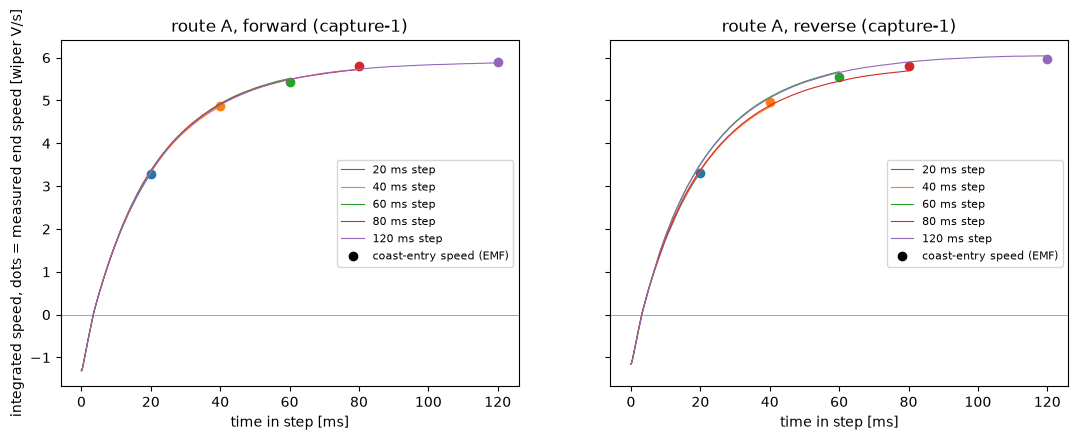

,J_i [A per wiper V/s2],omega_0 forward [wiper V/s],omega_0 reverse [wiper V/s],rms residual [wiper V/s],J_i forward only,J_i reverse only
capture-1,0.00160,-1.31135,-1.15298,0.07659,0.00159,0.00162
capture-2,0.00163,-1.06153,-0.94943,0.08605,0.00179,0.00151
capture-3,0.00149,-1.85404,-1.65688,0.11022,0.00151,0.00148
capture-4,0.00146,-1.99678,-1.84361,0.07725,0.00150,0.00143
capture-5,0.00141,-2.47382,-2.04138,0.13895,0.00129,0.00154
mean,0.00152,-1.73950,-1.52886,0.09781,0.00154,0.00152
min,0.00141,-2.47382,-2.04138,0.07659,0.00129,0.00143
max,0.00163,-1.06153,-0.94943,0.13895,0.00179,0.00162
cv [%],6.33654,32.28397,30.24303,27.32971,11.52686,4.80850


In [8]:
def integrate(cur, w0, Ji, ic, iv):
    # Forward Euler of Ji dw/dt = i - ic sign(w) - iv w at the sample rate.
    w = np.empty(len(cur))
    x = w0
    for k in range(len(cur)):
        x = x + DT * (cur[k] - ic * np.sign(x) - iv * x) / Ji
        w[k] = x
    return w

def route_a(sub, ic, iv, current="trace", w0_from=None, dirs=(1, -1)):
    # Ji shared over the steps of `sub`, one entry speed per direction unless
    # w0_from names a column that supplies it per step.
    def per_step(x):
        Ji, w0 = x[0], {1: x[1], -1: x[2]}
        rows = []
        for _, row in sub.iterrows():
            cur = row["cur"] if current == "trace" else np.full(len(row["cur"]), row["cur"].mean())
            start = row[w0_from] if w0_from else w0[row["dir"]]
            w = integrate(cur, start, Ji, ic[row["dir"]], iv[row["dir"]])
            rows.append({"recording": row["recording"], "dir": row["dir"], "step_ms": row["step_ms"],
                         "omega_T": row["omega_T"], "omega_fit": w[-1], "travel_V": row["travel_V"],
                         "travel_fit_V": np.sum(w) * DT})
        return pd.DataFrame(rows)
    def resid(x):
        tab = per_step(x)
        return (tab["omega_fit"] - tab["omega_T"]).to_numpy()
    res = least_squares(resid, [0.0012, -2.0, -2.0], bounds=([1e-5, -20, -20], [1, 20, 20]))
    tab = per_step(res.x)
    return {"Ji": res.x[0], "w0": {1: res.x[1], -1: res.x[2]},
            "rms": np.sqrt(np.mean(res.fun ** 2)), "steps": tab}

fits_a = {}
rows = []
for name, sub in steps.groupby("recording"):
    f = route_a(sub, I_C, I_V)
    f["fwd"] = route_a(sub[sub["dir"] == 1], I_C, I_V)
    f["rev"] = route_a(sub[sub["dir"] == -1], I_C, I_V)
    fits_a[name] = f
    rows.append({"recording": name, "J_i [A per wiper V/s2]": f["Ji"],
                 "omega_0 forward [wiper V/s]": f["w0"][1], "omega_0 reverse [wiper V/s]": f["w0"][-1],
                 "rms residual [wiper V/s]": f["rms"],
                 "J_i forward only": f["fwd"]["Ji"], "J_i reverse only": f["rev"]["Ji"]})
route_a_tab = pd.DataFrame(rows).set_index("recording")
J_A = route_a_tab["J_i [A per wiper V/s2]"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
name = next(iter(fits_a))
f = fits_a[name]
for ax, d in zip(axes, (1, -1)):
    sub = steps[(steps["recording"] == name) & (steps["dir"] == d)].sort_values("step_ms")
    for _, row in sub.iterrows():
        w = integrate(row["cur"], f["w0"][d], f["Ji"], I_C[d], I_V[d])
        line, = ax.plot(np.arange(len(w)) * DT * 1e3, w, lw=0.8, label=f"{row['step_ms']} ms step")
        ax.plot(row["T_s"] * 1e3, row["omega_T"], "o", color=line.get_color(), ms=6)
    ax.plot([], [], "ko", label="coast-entry speed (EMF)")
    ax.axhline(0, color="grey", lw=0.5)
    ax.set_xlabel("time in step [ms]")
    ax.set_title(f"route A, {DIRS[d]} ({name})")
    ax.legend(fontsize=8)
axes[0].set_ylabel("integrated speed, dots = measured end speed [wiper V/s]")
plt.show()

with_summary(route_a_tab).round(5)


The per-step residuals of the shared fit, pooled over recordings:


In [9]:
resid_tab = pd.concat([f["steps"] for f in fits_a.values()])
resid_tab["residual"] = resid_tab["omega_fit"] - resid_tab["omega_T"]
resid_tab["residual_pct"] = resid_tab["residual"] / resid_tab["omega_T"] * 100
(resid_tab.assign(direction=resid_tab["dir"].map(DIRS))
    .groupby(["direction", "step_ms"])[["omega_T", "omega_fit", "residual", "residual_pct", "travel_V", "travel_fit_V"]]
    .mean().round(3))


omega_T  omega_fit  residual  residual_pct  travel_V  \
direction step_ms                                                         
forward   20         3.278      3.272    -0.005        -0.001    -0.001   
          40         4.909      4.901    -0.008        -0.162     0.090   
          60         5.494      5.528     0.034         0.616     0.202   
          80         5.814      5.775    -0.039        -0.664     0.309   
          120        5.935      5.952     0.018         0.297     0.561   
reverse   20         3.316      3.321     0.005         0.165    -0.005   
          40         4.972      5.027     0.055         1.105     0.084   
          60         5.567      5.549    -0.018        -0.314     0.197   
          80         5.883      5.763    -0.119        -2.033     0.307   
          120        5.953      6.033     0.080         1.358     0.564   

                   travel_fit_V  
direction step_ms                
forward   20              0.026  
          40              0.110  
          60              0.215  
          80              0.328  
          120             0.566  
reverse   20              0.028  
          40              0.115  
          60              0.219  
          80              0.330  
          120             0.575

Findings:

- $J_i$ is 0.00152 A per wiper V/s$^2$ on average, 0.00141 to 0.00163
  across the five captures, a spread of 6.3%. The fitted entry speeds are
  -1.0 to -2.5 wiper V/s, the residual reverse motion from the
  repositioning move, and they scatter by about 30%: the repositioning move
  repeats itself only loosely, which is the premise this fit rests on and
  the weakest part of it.
- The fit reproduces the ten speeds of a capture with an rms residual of
  0.077 to 0.139 wiper V/s, 1.6 to 2.3% of the measured speeds. The
  residual no longer has the shape it had on the USB session. It runs
  under 1% at every step length except the 80 ms reverse (-2.0%) and the
  120 ms reverse (+1.4%), and the sign alternates rather than sweeping
  from early to late, so there is no systematic mismatch between the
  model's approach to steady speed and the mechanism's left to explain.
- Refitted per direction, $J_i$ is 0.00154 forward (0.00129 to 0.00179)
  and 0.00152 reverse (0.00143 to 0.00162). The two agree to 1%, and both
  spreads are larger than the shared fit's, since each rests on five
  speeds and two parameters.
- $J_i$ is a mechanical constant and must not depend on the supply. The USB
  cross-check of section 7.1 puts it 6.1% below this, inside the 6.3%
  capture-to-capture spread of the primary fit, so this dataset does not
  find a supply dependence.

The next table tests the modeling choices. The mean-current variant
replaces the trace with its step mean. The coast-friction variant replaces
the drive-side line with the coast friction of section 5.1 scaled by
$J_i$ itself, $i_c = J_i a$ and $i_v = J_i b$, which makes route A
independent of the duty grid. The pot variant fixes the entry speed of
every step at the slope of the pot over its first 5 ms.


In [10]:
def route_a_coast(sub, a, b):
    # Friction from the coast fit, scaled by the Ji being fitted.
    def resid(x):
        Ji, w0 = x[0], {1: x[1], -1: x[2]}
        return np.array([integrate(row["cur"], w0[row["dir"]], Ji, Ji * a, Ji * b)[-1] - row["omega_T"]
                         for _, row in sub.iterrows()])
    res = least_squares(resid, [0.0012, -2.0, -2.0], bounds=([1e-5, -20, -20], [1, 20, 20]))
    return {"Ji": res.x[0], "rms": np.sqrt(np.mean(res.fun ** 2))}

variants = {"measured current, entry speed fitted (route A)": {n: f for n, f in fits_a.items()}}
variants["step-mean current, entry speed fitted"] = {
    n: route_a(sub, I_C, I_V, current="mean") for n, sub in steps.groupby("recording")}
variants["measured current, coast friction scaled by J_i"] = {
    n: route_a_coast(sub, A_COAST.mean(), B_COAST.mean()) for n, sub in steps.groupby("recording")}
variants["measured current, entry speed from the pot"] = {
    n: route_a(sub, I_C, I_V, w0_from="w0_pot") for n, sub in steps.groupby("recording")}

rows = []
for label, fs in variants.items():
    j = pd.Series({n: f["Ji"] for n, f in fs.items()})
    rows.append({"variant": label, "J_i mean": j.mean(), "min": j.min(), "max": j.max(),
                 "cv [%]": j.std() / j.mean() * 100, "vs route A [%]": (j.mean() / J_A.mean() - 1) * 100,
                 "rms residual [wiper V/s]": np.mean([f["rms"] for f in fs.values()])})
J_A_COAST = pd.Series({n: f["Ji"] for n, f in variants["measured current, coast friction scaled by J_i"].items()})
variant_tab = pd.DataFrame(rows).set_index("variant")
variant_tab.round(5)


,J_i mean,min,max,cv [%],vs route A [%],rms residual [wiper V/s]
variant,,,,,,
"measured current, entry speed fitted (route A)",0.00152,0.00141,0.00163,6.33654,0.00000,0.09781
"step-mean current, entry speed fitted",0.00190,0.00184,0.00197,3.10947,24.74936,0.16151
"measured current, coast friction scaled by J_i",0.00143,0.00141,0.00146,1.86458,-5.95283,0.13006
"measured current, entry speed from the pot",0.00146,0.00142,0.00154,3.25023,-3.97124,0.46401


Findings:

- The step-mean current inflates $J_i$ by 25%, because the mean spreads
  the early current peak over the whole step and the model then needs
  more inertia to end at the same speed. The residual (0.162 against
  0.098 wiper V/s) barely flags the error, since the fitted entry speeds
  absorb most of it. The per-sample trace is required.
- With the coast friction in place of the drive-side line, $J_i$ is
  0.00143 (0.00141 to 0.00146), 6% below route A with a 1.9% spread. So
  the choice of friction source moves the answer by 6% here, against 12%
  on the USB session, and the two friction sources are closer together on
  this supply than they were on that one.
- Fixing the entry speed from the pot raises the residual to 0.46 wiper
  V/s, nearly five times the fitted value, and moves the mean $J_i$ by
  4%. The pot's error partly averages out over the five steps of a
  direction, but nothing about the resulting 0.00146 owes anything to the
  fit quality. The entry speed still has to be fitted (section 7.2
  quantifies the pot's problem).

Two model-free cross-checks follow. The first fits the five coast-entry
speeds of each capture and direction with an exponential approach,
$\omega(T) = \omega_{ss} - (\omega_{ss} - \omega_0)\,e^{-T/\tau}$, with no
current and no friction in it. Its time constant is compared with the one
the fitted constants imply. Under constant applied voltage the current
falls with speed at a rate $k_i = -di/d\omega$, read here from the current
at the end of each step against the speed at the end of each step, and
the linearized equation gives the rise time constant $\tau = J_i / (k_i +
i_v)$. The friction-only constant $J_i / i_v$, the time constant of a coast
in the viscous regime, is listed for reference.

The second is the initial-slope estimate from the 20 ms step alone,
$J_i = \int (i - i_c\,\mathrm{sign}\,\omega - i_v\,\omega)\,dt \,/\,
(\omega_T - \omega_0)$, with the friction evaluated on a straight ramp
from $\omega_0$ to $\omega_T$ and $\omega_0$ taken from the pot's first
5 ms, the only entry speed that is measured on its own. It is the one
estimate in this notebook that leans on a pot derivative, and it is kept
because it shows what that costs.


In [11]:
def rise(T, wss, w0, tau):
    return wss - (wss - w0) * np.exp(-T / tau)

rows = []
for (name, d), sub in steps.groupby(["recording", "dir"]):
    (wss, w0, tau), _ = curve_fit(rise, sub["T_s"], sub["omega_T"], p0=[6.0, -3.0, 0.02])
    i_end = np.array([row["cur"][-40:].mean() for _, row in sub.iterrows()])
    k_i = -np.polyfit(sub["omega_T"], i_end, 1)[0]
    Ji = fits_a[name]["Ji"]
    rows.append({"recording": name, "direction": DIRS[d],
                 "omega_ss, exponential [wiper V/s]": wss, "omega_0, exponential [wiper V/s]": w0,
                 "tau, exponential [ms]": tau * 1e3,
                 "k_i = -di/domega [A per wiper V/s]": k_i,
                 "tau = J_i / (k_i + i_v) [ms]": Ji / (k_i + I_V[d]) * 1e3,
                 "J_i / i_v [ms]": Ji / I_V[d] * 1e3})
tau_tab = pd.DataFrame(rows).set_index(["recording", "direction"])
TAU_EXP = tau_tab["tau, exponential [ms]"]
with_summary(tau_tab).round(3)


omega_ss, exponential [wiper V/s]  \
recording direction                                      
capture-1 reverse                                5.968   
          forward                                5.953   
capture-2 reverse                                5.950   
          forward                                6.018   
capture-3 reverse                                6.143   
          forward                                5.999   
capture-4 reverse                                5.959   
          forward                                6.007   
capture-5 reverse                                5.982   
          forward                                5.882   
mean                                             5.986   
min                                              5.882   
max                                              6.143   
cv [%]                                           1.124   

                     omega_0, exponential [wiper V/s]  tau, exponential [ms]  \
recording direction                                                            
capture-1 reverse                              -0.921                 21.036   
          forward                              -0.413                 22.931   
capture-2 reverse                              -0.764                 21.116   
          forward                               0.815                 25.954   
capture-3 reverse                               0.034                 25.429   
          forward                              -0.351                 23.605   
capture-4 reverse                              -2.140                 18.756   
          forward                              -1.173                 20.996   
capture-5 reverse                              -1.240                 19.406   
          forward                              -2.857                 18.065   
mean                                           -0.901                 21.730   
min                                            -2.857                 18.065   
max                                             0.815                 25.954   
cv [%]                                        116.550                 12.421   

                     k_i = -di/domega [A per wiper V/s]  \
recording direction                                       
capture-1 reverse                                 0.071   
          forward                                 0.073   
capture-2 reverse                                 0.071   
          forward                                 0.086   
capture-3 reverse                                 0.069   
          forward                                 0.072   
capture-4 reverse                                 0.067   
          forward                                 0.068   
capture-5 reverse                                 0.075   
          forward                                 0.068   
mean                                              0.072   
min                                               0.067   
max                                               0.086   
cv [%]                                            7.548   

                     tau = J_i / (k_i + i_v) [ms]  J_i / i_v [ms]  
recording direction                                                
capture-1 reverse                          21.008         312.511  
          forward                          20.571         352.772  
capture-2 reverse                          21.344         318.812  
          forward                          18.104         359.885  
capture-3 reverse                          20.138         290.275  
          forward                          19.451         327.671  
capture-4 reverse                          20.203         285.444  
          forward                          20.149         322.218  
capture-5 reverse                          17.503         274.256  
          forward                          19.409         309.589  
mean                                       19.788 

In [12]:
rows = []
for _, row in steps[steps["step_ms"] == 20].iterrows():
    d = row["dir"]
    ramp = np.linspace(row["w0_pot"], row["omega_T"], len(row["cur"]))
    net = np.sum(row["cur"] - I_C[d] * np.sign(ramp) - I_V[d] * ramp) * DT
    rows.append({"recording": row["recording"], "direction": DIRS[d],
                 "omega_0, pot 5 ms [wiper V/s]": row["w0_pot"], "omega_T [wiper V/s]": row["omega_T"],
                 "net current integral [A s]": net,
                 "J_i, initial slope": net / (row["omega_T"] - row["w0_pot"])})
slope_tab = pd.DataFrame(rows).set_index(["recording", "direction"])
J_SLOPE = slope_tab["J_i, initial slope"]
with_summary(slope_tab).round(5)


omega_0, pot 5 ms [wiper V/s]  omega_T [wiper V/s]  \
recording direction                                                       
capture-1 forward                         -0.90279              3.28839   
          reverse                         -1.12063              3.30175   
capture-2 forward                         -1.73345              3.59134   
          reverse                         -2.77982              3.34195   
capture-3 forward                         -1.35539              3.26768   
          reverse                         -2.03995              3.34642   
capture-4 forward                         -1.05208              3.25103   
          reverse                         -2.27955              3.17789   
capture-5 forward                         -1.87181              2.99072   
          reverse                         -1.20823              3.41261   
mean                                      -1.63437              3.29698   
min                                       -2.77982              2.99072   
max                                       -0.90279              3.59134   
cv [%]                                    37.36631              4.69369   

                     net current integral [A s]  J_i, initial slope  
recording direction                                                  
capture-1 forward                       0.00749             0.00179  
          reverse                       0.00739             0.00167  
capture-2 forward                       0.00789             0.00148  
          reverse                       0.00792             0.00129  
capture-3 forward                       0.00771             0.00167  
          reverse                       0.00776             0.00144  
capture-4 forward                       0.00761             0.00177  
          reverse                       0.00784             0.00144  
capture-5 forward                       0.00820             0.00169  
          reverse                       0.00757             0.00164  
mean                                    0.00774             0.00159  
min                                     0.00739             0.00129  
max                                     0.00820             0.00179  
cv [%]                                  3.05450            10.30386

Findings:

- The exponential approach puts the steady speed at 5.88 to 6.14 wiper V/s
  (a 1.1% spread) and the time constant at 18.1 to 26.0 ms, 21.7 on
  average, with the entry speed as a third free parameter on five points.
  On the USB session the same fit ran from 22 to 91 ms; at these speeds it
  is a usable estimate again, and the free entry speed still scatters from
  -2.9 to +0.8 wiper V/s.
- The fitted constants imply 17.5 to 21.3 ms (19.8 on average) from
  $J_i / (k_i + i_v)$, with $k_i$ of 0.067 to 0.086 A per wiper V/s, and
  the current tails of section 5.2 read 17.7 to 18.7 ms. All three now
  agree on a rise time constant near 20 ms, where on USB the exponential
  had to be thrown out to get that agreement.
- The friction-only time constant $J_i / i_v$ is 0.27 to 0.36 s, about
  sixteen times the rise constant. Under voltage drive the back-EMF,
  through $k_i$, is what sets the rise, and mechanical friction adds a
  sixteenth of the damping.
- The initial-slope estimate gives 0.00159 A per wiper V/s$^2$ on average
  (0.00129 to 0.00179), 4.5% above route A with a 10.3% spread. The net
  current integral behind it is repeatable to 3.1%, so essentially all of
  that spread is the pot-derived entry speed, which scatters by 37%. It
  confirms the order of magnitude and the size of the entry-speed problem.

## 6. Route B, coast deceleration and the friction line

Coast decelerates the mechanism under friction alone, so by the equation
of the purpose section with $i = 0$, the coast constants of section 5.1
are the friction constants divided by the inertia, $a = i_c / J_i$ and
$b = i_v / J_i$. Each friction term therefore gives its own estimate,

$$J_i = \frac{i_c}{a}, \qquad J_i = \frac{i_v}{b},$$


In [13]:
ic_mean, iv_mean = np.mean(list(I_C.values())), np.mean(list(I_V.values()))
route_b_tab = pd.DataFrame({
    "a [wiper V/s2]": A_COAST, "b [1/s]": B_COAST,
    "J_i = i_c / a": ic_mean / A_COAST, "J_i = i_v / b": iv_mean / B_COAST,
    "J_i = i_c / a, forward": I_C[1] / A_COAST, "J_i = i_c / a, reverse": I_C[-1] / A_COAST,
    "J_i = i_v / b, forward": I_V[1] / B_COAST, "J_i = i_v / b, reverse": I_V[-1] / B_COAST,
})
J_B_C, J_B_V = route_b_tab["J_i = i_c / a"], route_b_tab["J_i = i_v / b"]
with_summary(route_b_tab).round(5)


,a [wiper V/s2],b [1/s],J_i = i_c / a,J_i = i_v / b,"J_i = i_c / a, forward","J_i = i_c / a, reverse","J_i = i_v / b, forward","J_i = i_v / b, reverse"
capture-1,43.65279,2.74580,0.00116,0.00176,0.00127,0.00105,0.00165,0.00187
capture-2,40.80779,2.63335,0.00124,0.00184,0.00136,0.00113,0.00173,0.00195
capture-3,39.42519,2.80027,0.00129,0.00173,0.00141,0.00117,0.00162,0.00183
capture-4,39.91179,2.74006,0.00127,0.00176,0.00139,0.00115,0.00166,0.00187
capture-5,39.80115,2.88711,0.00127,0.00167,0.00139,0.00116,0.00157,0.00178
mean,40.71974,2.76132,0.00125,0.00175,0.00136,0.00113,0.00165,0.00186
min,39.42519,2.63335,0.00116,0.00167,0.00127,0.00105,0.00157,0.00178
max,43.65279,2.88711,0.00129,0.00184,0.00141,0.00117,0.00173,0.00195
cv [%],4.21496,3.35886,4.03510,3.36645,4.03510,4.03510,3.36645,3.36645


In [14]:
coast_i = {"Coulomb [A]": J_A.mean() * A_COAST.mean(),
           "viscous [A per wiper V/s]": J_A.mean() * B_COAST.mean(),
           "Coulomb / viscous [wiper V/s]": A_COAST.mean() / B_COAST.mean()}
drive_i = {"Coulomb [A]": (I_C[1], I_C[-1], ic_mean),
           "viscous [A per wiper V/s]": (I_V[1], I_V[-1], iv_mean),
           "Coulomb / viscous [wiper V/s]": (I_C[1] / I_V[1], I_C[-1] / I_V[-1], ic_mean / iv_mean)}
pd.DataFrame([
    {"term": term, "coast, scaled by route A J_i": coast_i[term],
     "drive line, forward": drive_i[term][0], "drive line, reverse": drive_i[term][1],
     "drive line, mean": drive_i[term][2],
     "coast vs drive mean [%]": (coast_i[term] / drive_i[term][2] - 1) * 100}
    for term in coast_i
]).set_index("term").round(4)


,"coast, scaled by route A J_i","drive line, forward","drive line, reverse","drive line, mean",coast vs drive mean [%]
term,,,,,
Coulomb [A],0.0619,0.0555,0.0460,0.0507,21.9277
viscous [A per wiper V/s],0.0042,0.0045,0.0051,0.0048,-13.2427
Coulomb / viscous [wiper V/s],14.7465,12.2075,8.9738,10.4928,40.5388


Findings:

- The Coulomb route gives $J_i$ of 0.00125 A per wiper V/s$^2$ (0.00116 to
  0.00129 across the spin-down captures, a 4.0% spread), 18% **below**
  route A. Per direction it is 0.00136 forward and 0.00113 reverse, a 20%
  asymmetry that comes straight from the 21% asymmetry of the drive-side
  Coulomb term.
- The viscous route gives 0.00175 (0.00167 to 0.00184), 15% above route A
  and 40% above the Coulomb route. The coast and the drive side still do
  not agree on how to split the friction, but the disagreement has moved.
  On the USB session the Coulomb terms agreed within 6% and the viscous
  terms were 57% apart; here the viscous terms agree within 13% (coast
  0.0042 against 0.0048 A per wiper V/s from the line) and it is the
  Coulomb terms that are 22% apart (0.0619 against 0.0507 A). The ratio
  $a / b$ of 14.8 wiper V/s against $i_c / i_v$ of 10.5 says the same
  thing, and the coast ratio sits above the drive ratio as it did before.
- The likely mechanism for the move is the speed range. The coast fit now
  runs from 8.4 wiper V/s down to zero and the friction line is matched
  out to 9.0, where on USB both stopped near 5. A Coulomb-plus-viscous
  model fitted over a wider range trades the two terms against each other
  differently, and section 5.1 shows the same trade inside one dataset:
  the pot route and the terminal route fit the same coasts and split them
  10% and 60% apart.
- Route B is the weaker measurement by construction. It is a quotient of
  two fitted constants, where route A uses the friction line only as a
  correction to the current, and section 5.3 showed that swapping the line
  for the coast friction moves route A by 6%.
- What is and is not independent. Route A and the Coulomb variant of
  route B share the drive-side line as input, so their 18% disagreement
  tests the coast fit's $a$ against the step data, with the line in common.
  The coast-friction variant of route A (0.00143) uses the coast fit in
  place of the line and lands between them. No pair of estimates here is
  free of shared input, and the term that moves an estimate most is now
  the Coulomb one.
- *Hypothesis (not tested here): the drive-side line and the coast see
  different Coulomb friction because they run at different currents through
  the same gear train, and a loaded mesh has more Coulomb drag than a
  coasting one. Under that reading neither term is wrong and the mechanical
  equation needs a load-dependent $i_c$, which a rise curve at a second
  duty would expose (section 8).*

## 7. Agreement and repeatability

The table collects every estimate of $J_i$ with its spread across
captures and its difference from route A. The pairwise differences
follow, then the same pipeline on the USB captures, then the verdict, then
the comparison of the two speed signals that decides which route works.


In [15]:
def summary(label, s, note):
    return {"estimate": label, "J_i mean [A per wiper V/s2]": s.mean(), "min": s.min(), "max": s.max(),
            "cv [%]": s.std() / s.mean() * 100, "recordings": len(s),
            "vs route A [%]": (s.mean() / J_A.mean() - 1) * 100, "inputs": note}

estimates = pd.DataFrame([
    summary("route A, rise curve", J_A, "steps, drive-side friction line"),
    summary("route A, coast friction variant", J_A_COAST, "steps, coast fit"),
    summary("initial slope, 20 ms step", J_SLOPE, "20 ms steps, pot entry speed, drive-side line"),
    summary("route B, Coulomb, i_c / a", J_B_C, "coast fit a, drive-side line"),
    summary("route B, viscous, i_v / b", J_B_V, "coast fit b, drive-side line"),
]).set_index("estimate")
pd.set_option("display.max_colwidth", 60)
estimates.round(5)


,J_i mean [A per wiper V/s2],min,max,cv [%],recordings,vs route A [%],inputs
estimate,,,,,,,
"route A, rise curve",0.00152,0.00141,0.00163,6.33654,5,0.00000,"steps, drive-side friction line"
"route A, coast friction variant",0.00143,0.00141,0.00146,1.86458,5,-5.95283,"steps, coast fit"
"initial slope, 20 ms step",0.00159,0.00129,0.00179,10.30386,10,4.45894,"20 ms steps, pot entry speed, drive-side line"
"route B, Coulomb, i_c / a",0.00125,0.00116,0.00129,4.03510,5,-17.87246,"coast fit a, drive-side line"
"route B, viscous, i_v / b",0.00175,0.00167,0.00184,3.36645,5,15.36832,"coast fit b, drive-side line"


In [16]:
names = estimates.index.tolist()
means = estimates["J_i mean [A per wiper V/s2]"]
pairs = pd.DataFrame([[(means[r] / means[c] - 1) * 100 for c in names] for r in names],
                     index=names, columns=names)
pairs.round(1)


,"route A, rise curve","route A, coast friction variant","initial slope, 20 ms step","route B, Coulomb, i_c / a","route B, viscous, i_v / b"
"route A, rise curve",0.0,6.3,-4.3,21.8,-13.3
"route A, coast friction variant",-6.0,0.0,-10.0,14.5,-18.5
"initial slope, 20 ms step",4.5,11.1,0.0,27.2,-9.5
"route B, Coulomb, i_c / a",-17.9,-12.7,-21.4,0.0,-28.8
"route B, viscous, i_v / b",15.4,22.7,10.4,40.5,0.0


### 7.1 The same measurement on USB

2S is the dataset every constant above comes from. The same three campaigns
were captured on a laptop USB port in the same session, on the same board and
the same servo, and running the pipeline over them is a cross-check on the
trends rather than a second measurement. The USB rail droops about 3.5% across
the duty range and dips over 20% on spin-up, so a friction line fitted against
duty there has the rail's droop folded into it; that is why it is a check and
not an input. $J_i$ is the interesting row, since it is a mechanical constant
and cannot legitimately depend on which supply was plugged in.


In [17]:
def pipeline(dataset):
    # k_e and the coast friction from the spin-down coasts, the friction line
    # from the duty grid, route A on the step series: the same functions
    # sections 5 and 6 ran on 2S, in one pass over another dataset.
    k_es, a_c, b_c, entry = [], [], [], []
    for cap in dataset.captures("bridge"):
        sp, _ = sweep(dataset, "bridge", cap, "spindown")
        segs = coast_segments(sp, rail_V(sp))
        slope = np.mean([np.sum(c["e"][c["mask"]]) * DT /
                         (np.median(c["p"][-1000:]) - np.median(c["p"][:3])) for c in segs])
        term = joint_fit(segs, "e", True, False)
        k_es.append(slope)
        a_c.append(term["a"] / slope)
        b_c.append(term["b"])
        entry += [c["e"][c["mask"]][:20].mean() / slope for c in segs]
    k_e, v_match = float(np.mean(k_es)), float(np.ceil(max(entry)))
    g = pd.DataFrame(sum((grid_steps(cap, sweep(dataset, "grid", cap)[0])
                          for cap in dataset.captures("grid")), []))
    ic, iv = {}, {}
    for d in DIRS:
        k = np.polyfit(*[g[(g["dir"] == d) & (g["v_ss"] <= v_match)][c] for c in ("v_ss", "i_ss")], 1)
        ic[d], iv[d] = k[1], k[0]
    st = pd.DataFrame(sum((step_records(cap, {ms: sweep(dataset, "stepcoast", cap, f"step{ms}")
                                              for ms in STEP_MS}, k_e)
                           for cap in dataset.captures("stepcoast")), []))
    ji = pd.Series({n: route_a(s, ic, iv)["Ji"] for n, s in st.groupby("recording")})
    return {
        "supply": dataset.supply,
        "rail during a 120 ms step [V]": float(np.mean([rail_V(sweep(dataset, "stepcoast", c, "step120")[0])
                                                        for c in dataset.captures("stepcoast")])),
        "rail tap at rest [V]": float(np.mean([board.vsys_v(sweep(dataset, "stepcoast", c, "step120")[1]["vbus_counts"])
                                               for c in dataset.captures("stepcoast")])),
        "k_e [V per wiper V/s]": k_e,
        "a, coast [wiper V/s2]": float(np.mean(a_c)),
        "b, coast [1/s]": float(np.mean(b_c)),
        "coast entry ceiling [wiper V/s]": v_match,
        "i_c [A]": float(np.mean(list(ic.values()))),
        "i_v [A per wiper V/s]": float(np.mean(list(iv.values()))),
        "speed at the end of a 120 ms step [wiper V/s]": st[st["step_ms"] == 120]["omega_T"].mean(),
        "J_i, route A [A per wiper V/s2]": ji.mean(),
        "J_i spread over recordings [%]": ji.std() / ji.mean() * 100,
    }

primary = {
    "supply": ds.supply,
    "rail during a 120 ms step [V]": float(np.mean([rail_V(steps_raw[c][120][0]) for c in steps_raw])),
    "rail tap at rest [V]": float(np.mean([board.vsys_v(steps_raw[c][120][1]["vbus_counts"]) for c in steps_raw])),
    "k_e [V per wiper V/s]": K_E,
    "a, coast [wiper V/s2]": A_COAST.mean(),
    "b, coast [1/s]": B_COAST.mean(),
    "coast entry ceiling [wiper V/s]": V_MATCH,
    "i_c [A]": ic_mean,
    "i_v [A per wiper V/s]": iv_mean,
    "speed at the end of a 120 ms step [wiper V/s]": steps[steps["step_ms"] == 120]["omega_T"].mean(),
    "J_i, route A [A per wiper V/s2]": J_A.mean(),
    "J_i spread over recordings [%]": J_A.std() / J_A.mean() * 100,
}
cross = pd.DataFrame([primary, pipeline(ds_usb)]).set_index("supply").T
cross["USB vs 2S [%]"] = (cross[ds_usb.supply] / cross[ds.supply] - 1) * 100
cross.round(4)


supply,2s,usb,USB vs 2S [%]
rail during a 120 ms step [V],7.4849,4.6202,-38.2733
rail tap at rest [V],6.1295,3.8559,-37.0925
k_e [V per wiper V/s],0.2891,0.2891,-0.0189
"a, coast [wiper V/s2]",40.7197,31.4288,-22.8168
"b, coast [1/s]",2.7613,4.1840,51.5228
coast entry ceiling [wiper V/s],9.0000,5.0000,-44.4444
i_c [A],0.0507,0.0335,-33.8966
i_v [A per wiper V/s],0.0048,0.0056,16.4248
speed at the end of a 120 ms step [wiper V/s],5.9438,3.1888,-46.3503
"J_i, route A [A per wiper V/s2]",0.0015,0.0014,-6.0772


Verdict:

- Route A stands as the inertia measurement of this notebook, $J_i =
  0.00152$ A per wiper V/s$^2$ with a 6.3% spread across five captures.
  The repeatability that the coast-entry EMF speed axis bought is intact.
- The four estimates span 40%, from the Coulomb route B at 0.00125 to the
  viscous route B at 0.00175, with route A and its coast-friction variant
  (0.00143) and the initial slope (0.00159) between them. Route A now sits
  in the middle of the bracket rather than at its edge. That is the
  agreement this notebook can claim, and it is a wider bracket than the
  USB session's because the two ends of it have swapped which friction
  term they disagree about (section 6).
- The USB cross-check moves $J_i$ by -6.1%, inside the primary fit's own
  6.3% capture-to-capture spread, on a rail 38% lower. $k_e$ moves by
  0.02%. Neither is evidence of a supply dependence in a mechanical
  constant, which is the outcome I wanted from that table.
- The implied mechanical rise time constant under 30% drive is near 20 ms
  by all three routes, and the friction-only constant $J_i / i_v$ is about
  0.32 s.

### 7.2 The two speed signals

The last tables show why the coast EMF is the speed signal for this
measurement. The rise curve needs the speed at the end of a 20 or 40 ms
step. From the pot that speed is a slope over the last 5 ms of the step,
and the acceleration over the step is the difference of two such slopes
divided by the step length, or a quadratic through the whole step. From the
EMF it is a 1 ms average with the pot ripple absent. The first table
compares the spread of each across the ten steps of a length (five
captures, two directions). The second measures what the pot brings to the
job on its own: its noise with the shaft mechanically stopped, and the
speed a one-tick difference of it reports from a servo that is not moving.


In [18]:
def cv(s):
    return np.std(s) / abs(np.mean(s)) * 100

rows = []
for ms in (20, 40):
    sub = steps[steps["step_ms"] == ms]
    acc_pot = (sub["wT_pot"] - sub["w0_pot"]) / sub["T_s"]
    acc_quad = np.array([2 * np.polyfit(np.arange(len(row["pos"])) * DT, row["pos"], 2)[0]
                         for _, row in sub.iterrows()])
    w0_fit = np.array([fits_a[row["recording"]]["w0"][row["dir"]] for _, row in sub.iterrows()])
    acc_emf = (sub["omega_T"] - w0_fit) / sub["T_s"]
    for label, s in [("end speed, pot last 5 ms [wiper V/s]", sub["wT_pot"]),
                     ("end speed, EMF [wiper V/s]", sub["omega_T"]),
                     ("entry speed, pot first 5 ms [wiper V/s]", sub["w0_pot"]),
                     ("acceleration, pot end minus start [wiper V/s2]", acc_pot),
                     ("acceleration, pot quadratic fit [wiper V/s2]", acc_quad),
                     ("acceleration, EMF end minus fitted entry [wiper V/s2]", acc_emf)]:
        rows.append({"quantity": label, "step": f"{ms} ms", "mean": np.mean(s), "cv [%]": cv(s)})
signal_tab = pd.DataFrame(rows).set_index(["quantity", "step"]).unstack("step")
signal_tab.round(2)

# What the pot brings to a speed estimate at this time scale: its own noise
# with the shaft mechanically stopped, from the one-second baseline of every
# grid recording. The last column is the apparent speed a one-tick difference
# of the raw pot reads from a servo that is not moving.
SETTLE_N = 4000    # 200 ms, the mechanical settle at the head of the baseline
rows = []
for label, frames in (("2S", [grid_raw[c] for c in grid_raw]),
                      ("USB", [sweep(ds_usb, "grid", c)[0] for c in ds_usb.captures("grid")[:5]])):
    for df in frames:
        p = df[df["seg"] == 0]["pos"].to_numpy().astype(float)
        d = np.diff(p[SETTLE_N:])
        rows.append({"supply": label,
                     "pot sd, whole baseline [counts]": p.std(),
                     "pot sd, after the settle [counts]": p[SETTLE_N:].std(),
                     "one-tick difference sd [counts]": d.std(),
                     "apparent speed sd [counts/s]": d.std() / DT,
                     "apparent speed sd [wiper V/s]": d.std() / DT * board.v_adc_per_count})
noise_tab = pd.DataFrame(rows).groupby("supply").agg(["mean", "min", "max"]).T
display(signal_tab.round(2))
noise_tab.round(2)


mean         cv [%]  \
step                                                    20 ms   40 ms  20 ms   
quantity                                                                       
acceleration, EMF end minus fitted entry [wiper V/s2]  246.56  164.37   7.94   
acceleration, pot end minus start [wiper V/s2]         125.91  194.37  32.44   
acceleration, pot quadratic fit [wiper V/s2]           116.40  229.31  30.27   
end speed, EMF [wiper V/s]                               3.30    4.94   4.45   
end speed, pot last 5 ms [wiper V/s]                     0.88    5.79  63.69   
entry speed, pot first 5 ms [wiper V/s]                 -1.63   -1.98  35.45   

                                                              
step                                                   40 ms  
quantity                                                      
acceleration, EMF end minus fitted entry [wiper V/s2]   7.16  
acceleration, pot end minus start [wiper V/s2]         18.02  
acceleration, pot quadratic fit [wiper V/s2]            9.11  
end speed, EMF [wiper V/s]                              1.00  
end speed, pot last 5 ms [wiper V/s]                   19.47  
entry speed, pot first 5 ms [wiper V/s]                34.41

supply                                        2S       USB
pot sd, whole baseline [counts]   mean      8.04      3.04
                                  min       6.81      1.99
                                  max       9.24      3.61
pot sd, after the settle [counts] mean      1.21      1.35
                                  min       1.07      1.06
                                  max       1.48      2.15
one-tick difference sd [counts]   mean      1.46      1.53
                                  min       1.27      1.21
                                  max       1.75      2.40
apparent speed sd [counts/s]      mean  29231.76  30580.03
                                  min   25362.18  24212.32
                                  max   35029.65  47955.90
apparent speed sd [wiper V/s]     mean     23.55     24.64
                                  min      20.43     19.51
                                  max      28.22     38.64

Findings:

- The pot's end speed of the 20 ms step scatters by 64% across the ten
  steps and by 19% at 40 ms, and the accelerations built from it by 9 to
  32%, whether from end minus start or from a quadratic through the whole
  step. The EMF's end speed scatters by 4.5% at 20 ms and 1.0% at 40 ms.
- It is not only noisier, it is wrong. The pot puts the mean acceleration
  of the 20 ms step at 116 to 126 wiper V/s$^2$ and of the 40 ms step at
  194 to 229. The EMF has it the other way round, 247 at 20 ms falling to
  164 at 40 ms, which is the only ordering a first-order rise toward a
  steady speed can produce. The pot's version says the mechanism
  accelerates harder after 40 ms of drive than in its first 20 ms.
- The entry speed is worse still: the pot's first 5 ms scatter by 35% at
  20 ms and 34% at 40 ms, which is why section 5.3 fits that parameter
  instead of measuring it.
- The pot's noise table says where all of this comes from. Differenced one
  tick apart, the pot reports 29,000 counts/s of speed, 23.5 wiper V/s,
  from a shaft that is mechanically stopped. The fastest speed this
  notebook measures is 6.0 wiper V/s. A one-tick pot derivative is four
  times its own full-scale signal before the mechanism moves at all. A
  least-squares slope over the 100 samples of a 5 ms window averages that
  down hard, to under 0.1 wiper V/s, which is an order of magnitude below
  the 0.6 wiper V/s the table actually scatters by. So the pot's problem at
  this time scale is not its noise. It is that the wiper's volts per turn
  depend on where the wiper is, which is what notebook 06 measures
  directly: a local gain swinging 5.8-fold with position, worth about plus
  or minus a third on any speed differentiated from the pot.
- The raw standard deviation of the pot at rest, 8.0 counts on 2S, is not
  a noise floor. Nearly all of it is a settling transient in the first
  200 ms of the baseline, while the mechanism comes to rest after the seek
  that preceded it: after that the pot sits at 1.2 counts. The
  distinction matters because 8.0 counts differenced one tick apart would
  predict about 227,000 counts/s of apparent speed, and the measured
  figure is 29,000. The pot's noise is strongly correlated between
  consecutive samples, so treating its standard deviation as white
  overstates the derivative by a factor of eight. It is still four times
  the signal.

## 8. Limitations and open issues

- **The board is a hacked rig.** The bus telemetry stream couples into the
  current amplifier output on this board (section 1). It is flat at rest
  on this firmware build, but a few counts is a few milliamps, and the
  friction line of section 5.3 lives on 50 to 100 mA. Route A takes the
  line only as a correction, so a few milliamps there is well under its
  6% sensitivity, but route B is a quotient of the line and would carry
  it directly. This is a limitation of this board, not something I code
  around.
- **One unit, one duty.** All coefficients describe this one servo, and
  the rise curve was taken at 30% duty only. A rise curve at a second duty
  would test whether $J_i$ is independent of the current level, as it must
  be if the current-to-torque relation is linear, and would separate the
  load-dependent Coulomb friction the section 6 hypothesis proposes.
- **$J_i$ is $J / K_t$.** The inertia in SI units needs the torque
  constant and, for the motor shaft, the gear ratio. The gear ratio is
  known exactly, 234.73:1 from counted teeth, and notebook 06 carries it;
  the torque constant of this particular can is not measured here. $J_i$
  is the constant the mechanical equation in current units needs, and that
  equation is what the control loop sees.
- **The friction line is an input.** Route A and route B both take the
  drive-side line, recomputed here with the method of notebook 04, and
  section 6 shows the coast and the drive side disagree on the Coulomb
  term by 22%. Route A's sensitivity to swapping one for the other is 6%.
- **The entry speed is fitted.** Every step starts from residual reverse
  motion, and its speed is a free parameter per direction and capture,
  on the premise that the repositioning move repeats. The fitted values
  are -1.0 to -2.5 wiper V/s and scatter by 30%, so that premise is the
  loosest assumption in route A. A step from rest would remove the
  parameter, and neither the pot nor the ripple line can supply it: the
  ripple tachometer of notebook 06 needs about 10 ms of window to resolve
  a line, which is half the shortest step here.
- **Forward Euler at 50 us.** The integration step equals the sample
  period and the shortest time scale in the equation is the 20 ms rise,
  so the discretization error is below 0.3%. The current between samples
  is taken as the sample value.
- **Voltages are nominal-referenced.** Every voltage and current scales
  with the true VDD of this unit, so $J_i$ scales with it as well.

## 9. What the next notebooks use from here

- The inertia in current units, $J_i = 0.00152$ A per wiper V/s$^2$
  (0.00141 to 0.00163 across captures), as the constant of the
  mechanical equation $J_i\,\dot\omega = i - i_c\,\mathrm{sign}\,\omega -
  i_v\,\omega$.
- The EMF-to-speed slope $k_e = 0.289$ V per wiper V/s from this session's
  spin-down coasts, which the USB captures reproduce to 0.02%, and the
  coast friction $a = 40.7$ wiper V/s$^2$, $b = 2.76$ 1/s by the terminal
  route.
- The drive-side friction line, $i_c = 0.0555$ A forward and 0.0460 A
  reverse, $i_v = 0.0045$ and 0.0051 A per wiper V/s, over speeds to
  9 wiper V/s.
- The rise time constant under voltage drive, near 20 ms at 30% duty, and
  the current-speed lever $k_i$ of about 0.072 A per wiper V/s at 30%
  duty, for the electrical side in notebook 03's terms.
- The finding that the coast and drive-side Coulomb terms differ by 22%
  while the viscous terms agree within 13%, as an input to the
  reconciliation of friction and back-EMF across notebooks 03 and 04.
- The rule that speed at the end of a short step is read from the coast
  EMF, that the first three coast samples are not usable, and that the
  entry speed of a step that starts in motion is a fitted parameter, since
  the pot's ripple and noise defeat both.


## 10. Open discrepancies

Five things in this notebook do not add up. Each one gets its candidate
causes and the experiment that would tell them apart, because a discrepancy
without a discriminating test is just a caveat.

**1. The coast and the drive side disagree on Coulomb friction by 22%.**
The coast fit gives 0.0619 A in current units against 0.0507 A from the
drive-side line, and that gap is the whole of the 18% between route A and
the Coulomb route B (section 6). Candidates: (a) real, load-dependent
Coulomb drag, a mesh pushed by 0.5 A of drive current rubbing harder than a
coasting one; (b) an artifact of fit range, since the coast fit spans 8.4
wiper V/s down to zero while the line is a set of steady points from 1 to 9,
and a two-term friction model splits differently over different ranges;
(c) the board's bus coupling biasing the low-current end of the line, where
one telemetry frame in sixteen lands on a 46 mA reading.
*Discriminator, cheapest first:* refit each over the other's range - the
coast restricted to its 3 to 9 wiper V/s portion, the line restricted to the
same band. If the gap collapses it is (b). If it survives, drive the same
steady speed at two different currents by loading the output shaft, or by
comparing slow decay against fast decay at equal speed: (a) predicts the
Coulomb term follows the current, (c) predicts it follows the frame rate,
which the telemetry mask can change without touching the mechanism.

**2. The two coast routes split the same deceleration differently.**
Fitted to the EMF the coast is 40.7 wiper V/s$^2$ Coulomb and 2.76 1/s
viscous; fitted to the position trace of the same segments it is 36.8 and
4.43 (section 5.1). Both describe one curve. Candidates: the pot's periodic
ripple pulling the trajectory fit, which is strongest at low speed where the
Coulomb term dominates; or the EMF mask dropping samples late in the coast,
where the terminals fall toward the bias and the discriminator starts
rejecting.
*Discriminator:* fit both routes over an identical time window, and repeat
with the mask disabled and with the last 100 ms excluded. If the split
tracks the window, it is sample selection. A third speed axis, the ripple
line of notebook 06, is available for the first few milliseconds of a coast
before the current dies, and it agrees with neither or one of them.

**3. The rail tap reads 22% low against the driven terminal.**
The driven terminal says 7.48 V and the rail tap the firmware sampled at
rest says 6.13 V, on 2S; on USB the pair is 4.62 V and 3.86 V. That is a
22% gap on one supply and 20% on the other. A supply cannot be two numbers. Candidates: (a) the board entry's
declared rail divider, 15k/10k, is not what is fitted on board D; (b) the
metadata's rail sample is taken under load rather than at rest; (c) the
terminal route over-reads through the bias term.
*Discriminator:* (a) is already the leading candidate and is cheap to
settle, because converting the same rail-tap counts with the terminal
divider's own ratio of 3.06 instead of 2.5 lands within 0.3% of the driven
terminal on 2S and 2.2% on USB, against 20% and 22% as declared. That is
what a 6k8/3k3 tap fitted where the entry claims 15k/10k would do, and the
residual 2.2% on USB is the direction a real drop across the bridge would
push it. Read the two resistors on the board, or
meter VSYS at rest against a capture's own `vbus_counts`. Nothing in this
notebook depends on the answer, but the board entry does, and every notebook
that reads `vsys_v` will inherit it.

**4. $J_i$ differs by 6.1% between the two supplies.**
It is a mechanical constant and cannot. The difference sits inside the 6.3%
capture-to-capture spread of the primary fit, so it may be nothing.
Candidates: noise; or the friction line being matched to a different speed
ceiling on each supply (9.0 against 5.0 wiper V/s), which section 6 shows is
enough to move the split between the two friction terms.
*Discriminator:* refit the 2S line over the USB ceiling of 5.0 wiper V/s and
rerun route A. If $J_i$ walks toward the USB value, the matched range is
carrying it and neither number is a supply effect.

**5. The pot's noise at rest is 8.0 counts or 1.2 counts, depending on
where you look.** Over the whole one-second baseline the standard deviation
is 8.0 counts, and the noise atlas of notebook 07 quotes 8.7 from the same
kind of window. After the first 200 ms it is 1.2 counts, and differenced one
tick apart the pot gives 1.5 counts, 29,000 counts/s of apparent speed
rather than the 227,000 that 8.0 counts of white noise would predict.
Candidates: the head of the baseline is mechanical, the output shaft still
settling from the seek that preceded it; or it is electrical, a channel or
reference still recovering after the bridge was disabled.
*Discriminator:* capture a baseline that follows a long idle instead of a
seek. If the transient goes with the seek it is mechanical, and the pot's
noise figure for any estimator that differentiates should be quoted as the
1.2 count floor with its correlation, not as 8.7 counts of white noise. The
distinction is worth a factor of eight in every derivative built on it.
